# Video Frames for specific trials

This notebook uses the input_videos table locally to fetch the stimulus at corresponding timepoints in the trials, namely initial timepoint, decision point and reward timepoint.

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py # not on aws, as only for the Mathis lab sessions
%run run.py connect

2026-01-14 16:56:27,215::INFO::settings.py::Setting loglevel to INFO
2026-01-14 16:56:27,216::INFO::settings.py::Setting stores to {}
2026-01-14 16:56:27,217::INFO::settings.py::Setting database.misc.schema_prefix to 
2026-01-14 16:56:27,217::INFO::settings.py::Setting database.misc.create_tables to True
2026-01-14 16:56:27,219::INFO::settings.py::Setting enable_python_native_blobs to True
2026-01-14 16:56:27,219::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2026-01-14 16:56:27,220::INFO::settings.py::Setting database.user to root
2026-01-14 16:56:27,220::INFO::settings.py::Setting database.password to simple
2026-01-14 16:56:27,268::INFO::connection.py::Connected root@128.178.51.167:3309


Connecting root@128.178.51.167:3309


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.analysis import analysis
from vr4mice.schema import dlc, inputs_videos
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

In [5]:
from vr4mice.schema.inputs_videos import AlignedVideoFrame

In [6]:
aligned_videos = pd.DataFrame((AlignedVideoFrame() & f'dataset = "Pheasant_2024-08-15_2"').fetch(as_dict=True)[0])

In [7]:
from vr4mice.schema.base_analysis import DataFrame
df = DataFrame().get_data(
    key={"dataset": "Pheasant_2024-08-15_2"},
    columns=[
        "dataset",
        "step_time",
        "reward",
        "mouse_in_left",
        "mouse_in_right",
        "trial",
        "aperture",
        "iti",
        "trial_left_choice",
        "trial_duration",
        "x",
        "y"
    ],
)

In [8]:
merged_df = pd.merge_asof(df, aligned_videos, left_on='step_time', right_on='step_time', direction="forward")

In [106]:
# First non ITI frame
merged_df[((merged_df["trial"]==69) | (merged_df["trial"]==125)) & (merged_df["iti"]==0)].groupby('trial').first()[["frame_ids"]]

,frame_ids
trial,
69,64068
125,127656


In [107]:
# Reward frames on trials 69 and 90
merged_df[((merged_df["trial"]==69) | (merged_df["trial"]==125)) & (merged_df["reward"]==1)][["frame_ids"]]

,frame_ids
26264,64158
52748,127764


In [108]:
from vr4mice.schema.decision import DecisionPoints
decision_points = pd.DataFrame((DecisionPoints() & "threshold_uncertainty=0.3" & "dataset='Pheasant_2024-08-15_2'").fetch(as_dict=True))
decision_points = decision_points.explode(["trial", "proba_left", "aperture", "trial_length", "x", "y", "trial_left_choice", "trial_rewarded"])

In [109]:
decision_points["x"] = decision_points["x"].astype(float)
decision_points["y"] = decision_points["y"].astype(float)

In [110]:
merged_df['decision'] = 0

for _, row in decision_points.iterrows():
    # Filter merged_df for the current trial
    trial_mask = merged_df['trial'] == row['trial']
    df_trial = merged_df[trial_mask]
    
    # Calculate Euclidean distance: sqrt((x1-x2)^2 + (y1-y2)^2)
    distances = np.sqrt(
        (df_trial['x'] - row['x'])**2 + 
        (df_trial['y'] - row['y'])**2
    )
    
    # 3. Find the index of the minimum distance and update df1
    closest_index = distances.idxmin()
    merged_df.at[closest_index, 'decision'] = 1

In [111]:
# Decision frames on trials 69 and 125
merged_df[(merged_df["decision"]==1) & ((merged_df["trial"]==69) | (merged_df["trial"]==125))][["trial", "frame_ids"]]

,trial,frame_ids
26239,69,64099
52722,125,127702


In [43]:
from vr4mice.schema.inputs_videos import ProcessedVideo
import matplotlib.pyplot as plt

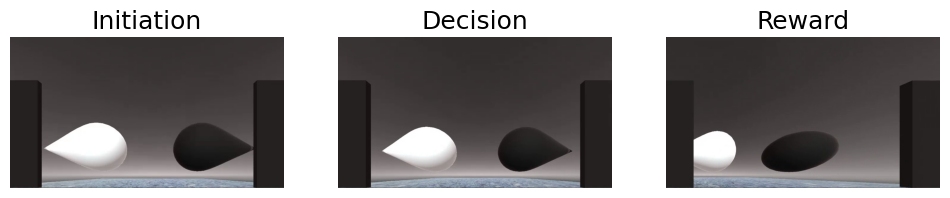

In [116]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=64068))
ax[0].set_title(f"Initiation")
ax[1].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=64099))
ax[1].set_title(f"Decision")
ax[2].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=64156)) 
ax[2].set_title(f"Reward")


ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")

fig.savefig("notebooks/Paper_figures/Figure_output/" + "video_frames_dual_occluder_decision_points_trial35.svg", 
            bbox_inches="tight", dpi=300, transparent=True)

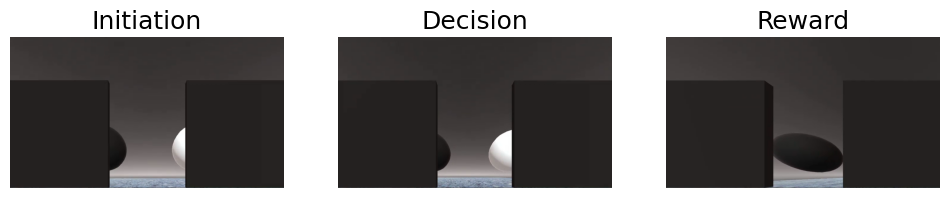

In [117]:


fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=127656))
ax[0].set_title(f"Initiation")
ax[1].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=127702))
ax[1].set_title(f"Decision")
ax[2].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=127762)) 
ax[2].set_title(f"Reward")


ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")

fig.savefig("notebooks/Paper_figures/Figure_output/" + "video_frames_dual_occluder_decision_points_trial47.svg", 
            bbox_inches="tight", dpi=300, transparent=True)